In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('infl_tweets.csv', index_col=0)
df.head()

,username,name,text,lang,in_reply_to,is_quote_status,retweeted_tweet,possibly_sensitive,favorited,date,...,view_count,view_count_state,retweet_count,place,is_translatable,edits_remaining,has_card,thumbnail_title,urls,hashtags
0,davidfaber,David Faber,LVMH sales not good led by 5% decline in Fashi...,en,NaN,False,NaN,NaN,False,2024-10-15 16:13:15+00:00,...,15275.0,EnabledWithCount,5,NaN,False,5.0,False,NaN,[],[]
1,davidfaber,David Faber,NYC losing another iconic restaurant: The 21 C...,en,NaN,False,NaN,0.0,False,2020-12-11 21:02:46+00:00,...,NaN,Enabled,791,NaN,False,5.0,False,NaN,[],[]
2,davidfaber,David Faber,⁦@DivesTech⁩ always brightens our day. https:/...,en,NaN,False,NaN,0.0,False,2023-08-29 14:43:53+00:00,...,39816.0,EnabledWithCount,8,NaN,False,5.0,False,NaN,[],[]
3,davidfaber,David Faber,Statement from PIF on PGA Commissioner Monahan...,en,NaN,False,NaN,0.0,False,2023-06-14 14:01:05+00:00,...,27073.0,EnabledWithCount,4,NaN,False,5.0,False,NaN,[],[]
4,davidfaber,David Faber,Steve Cohen has entered exclusive negotiations...,en,NaN,False,NaN,NaN,False,2020-08-29 01:53:26+00:00,...,NaN,Enabled,1059,NaN,False,5.0,False,NaN,[],[]


### Описание атрибутов ###
- **username** - Username
- **name** - Author of the tweet
- **text** - The full text of the tweet
- **lang** - The language of the tweet
- **in_reply_to** - The tweet ID this tweet is in reply to, if any
- **is_quote_status** - Indicates if the tweet is a quote status
- **retweeted_tweet** - The Tweet being retweeted (if any)
- **possibly_sensitive** - Indicates if the tweet content may be sensitive
- **favorited** - Indicates if the tweet is favorited
- **date** - The date and time when the tweet was created
- **quote_count** - The count of quotes for the tweet
- **reply_count** - The count of replies to the tweet
- **favorite_count** - The count of favorites or likes for the tweet
- **view_count** - The count of views
- **view_count_state** - The state of the tweet views
- **retweet_count** - The count of retweets for the tweet
- **place** - The location associated with the tweet
- **is_translatable** - Indicates if the tweet is translatable
- **edits_remaining** - The remaining number of edits allowed for the tweet
- **has_card** - Indicates if the tweet contains a card
- **thumbnail_title** - The title of the webpage displayed inside the tweet’s card
- **urls** - Information about URLs contained in the tweet
- **hashtags** - Hashtags included in the tweet text

### Количество собранных твитов ###

In [3]:
df.shape[0]

11820

### Самые популярные слова ###

In [4]:
from nltk.tokenize import TweetTokenizer
from string import punctuation
from nltk.corpus import stopwords

tw = TweetTokenizer()

special_symbols = ['“', '’', '”', '…', '...']
noise = stopwords.words("english") + list(punctuation) + special_symbols

def remove_stop_words(x):
    res = []
    for token in tw.tokenize(x.lower()):
        if token not in noise:
            res.append(token)
    return res

word_counts = df['text'].apply(remove_stop_words).explode().value_counts()[:25]

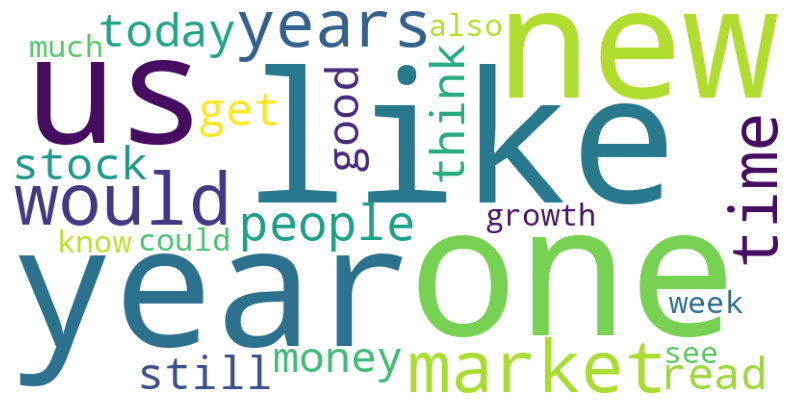

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts.to_dict())

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

/tmp/ipykernel_49192/1123629204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')


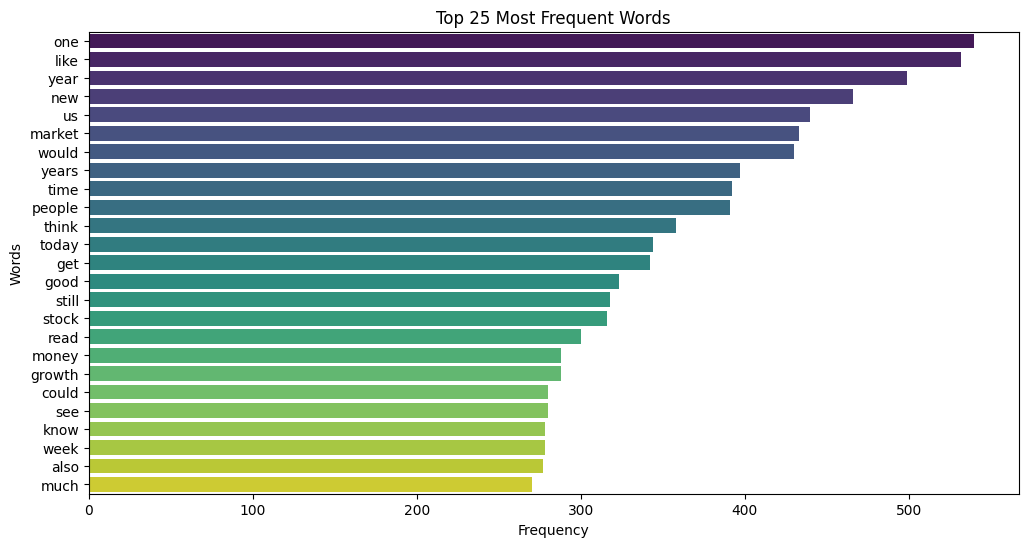

In [6]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Top 25 Most Frequent Words')
plt.show()

### Создание атрибута ticker ###

Данная модель находит тикер или название компании в тексте, но у нее есть один существенный недостаток - если в тексте упомянут более чем один тикер, модель его не находит. При попытке разделить текст на части и для каждой из них запускать модель, возникают несуществущие тикеры и названия компаний.

In [15]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("Jean-Baptiste/roberta-ticker")
model = AutoModelForTokenClassification.from_pretrained("Jean-Baptiste/roberta-ticker")

from transformers import pipeline

nlp = pipeline('ner', model=model, tokenizer=tokenizer, aggregation_strategy="simple")
 

In [14]:
df.loc[3]['text']

'Statement from PIF on PGA Commissioner Monahan’s illness: https://t.co/WhjKdQd5Bg'

In [13]:
nlp(df.loc[3]['text'])

[{'entity_group': 'TICKER',
  'score': np.float32(0.9996971),
  'word': ' PIF',
  'start': 15,
  'end': 18}]

Нахождение тикера с помощью регулярного выражения:

In [7]:
import sys
sys.path.append('/home/vasily/futures-price-prediction/')

from load_quotes import LIST_OF_TICKERS_1, LIST_OF_TICKERS_2, LIST_OF_TICKERS_3, LIST_OF_TICKERS_4, LIST_OF_TICKERS_5, LIST_OF_TICKERS_6

In [8]:
def read_file(path):
    with open(path, mode='r') as file:
        return [line.split() for line in file.readlines()]
    
read_file('../comps/comp_usernames_1')

[['AAPL', '@Apple', 'Apple'],
 ['META', '@meta', 'meta', 'Meta'],
 ['NVDA', '@nvidia', 'NVIDIA', 'Nvidia'],
 ['AMD', '@AMD', 'amd'],
 ['GOOG', '@google', 'Google', 'google'],
 ['XOM', '@exxonmobil'],
 ['MCD', '@McDonalds', 'McDonalds'],
 ['KO', '@CocaCola', 'CocaCola'],
 ['PFE', '@Pfizer', 'Pfizer'],
 ['PG', '@ProcterGamble', 'ProcterGamble']]

В твитах компания не всегда упомянается через тикер. Иногда можно встретить полное название компании или же ее юзернейм. Исходя из этого, лучше обрабатывать все возможное варианты упоминаний компании, но в этом подходе есть своя сложность, заключающаяся в том, что наименования компании приходится вводить вручную.

In [10]:
TICKERS = read_file('../comps/comp_usernames_1') + read_file('../comps/comp_usernames_2') + [[ticker] for ticker in LIST_OF_TICKERS_3] + [[ticker] for ticker in LIST_OF_TICKERS_4] + [[ticker] for ticker in LIST_OF_TICKERS_5] + [[ticker] for ticker in LIST_OF_TICKERS_6]

In [11]:
TICKERS

[['AAPL', '@Apple', 'Apple'],
 ['META', '@meta', 'meta', 'Meta'],
 ['NVDA', '@nvidia', 'NVIDIA', 'Nvidia'],
 ['AMD', '@AMD', 'amd'],
 ['GOOG', '@google', 'Google', 'google'],
 ['XOM', '@exxonmobil'],
 ['MCD', '@McDonalds', 'McDonalds'],
 ['KO', '@CocaCola', 'CocaCola'],
 ['PFE', '@Pfizer', 'Pfizer'],
 ['PG', '@ProcterGamble', 'ProcterGamble'],
 ['MSFT'],
 ['AMZN', '@amazonnews'],
 ['TSLA', '@Tesla'],
 ['GOOGL', '@google'],
 ['JPM'],
 ['JNJ', '@JNJNews'],
 ['V'],
 ['CMCSA', '@comcast'],
 ['PEP', '@PepsiCo'],
 ['T', '@ATT'],
 ['CSCO', '@Cisco'],
 ['DIS'],
 ['NKE', '@Nike'],
 ['VZ', '@verizonfios'],
 ['HD', '@HomeDepot'],
 ['UNH', '@UnitedHealthGrp'],
 ['CRM', '@salesforceapac'],
 ['NFLX', '@netflix'],
 ['INTC', '@intel'],
 ['BA', '@Boeing'],
 ['MRK', '@Merck'],
 ['LMT', '@LockheedMartin'],
 ['GILD', '@GileadSciences'],
 ['SBUX', '@Starbucks'],
 ['AMGN'],
 ['IBM'],
 ['HON'],
 ['PYPL'],
 ['LRCX'],
 ['MDLZ'],
 ['BKNG'],
 ['FDX'],
 ['EOG'],
 ['CIM'],
 ['DVN'],
 ['MPC'],
 ['CHK'],
 ['RRC'],
 

In [12]:
import regex as re

def is_ticker(x, ticker):
    prog = re.compile(f'(?<!\S)\$?{ticker}(?!\S)')
    res = prog.findall(x)
    return len(res) != 0

df['ticker'] = [[] for _ in range(df.shape[0])]

for names in TICKERS:
    for name in names:
        df['ticker'] = df.apply(lambda x: x['ticker'] + [names[0]] if is_ticker(x['text'], name) else x['ticker'], axis=1)
    
df['ticker'] = df['ticker'].apply(lambda x: None if len(x) == 0 else x)

In [13]:
df = df.explode('ticker')

In [14]:
df = df.dropna(subset=['ticker'])

In [15]:
df = df.reset_index().drop('index', axis=1)

In [16]:
df['ticker'] = df['ticker'].apply(lambda x: x[1:] if '$' in x else x)

Дата сет с размеченными тикерами:

In [19]:
df.head()

,username,name,text,lang,in_reply_to,is_quote_status,retweeted_tweet,possibly_sensitive,favorited,date,...,view_count_state,retweet_count,place,is_translatable,edits_remaining,has_card,thumbnail_title,urls,hashtags,ticker
0,davidfaber,David Faber,The chance of $MSFT winning an appeal of the ...,en,NaN,False,NaN,0.0,False,2023-04-26 12:23:58+00:00,...,EnabledWithCount,19,NaN,False,5.0,False,NaN,[],[],MSFT
1,PhilipEtienne,Voltaire,We love and appreciate all the volunteers at t...,en,NaN,False,NaN,0.0,False,2024-05-06 13:54:43+00:00,...,EnabledWithCount,1,NaN,False,5.0,False,NaN,[],[],NVDA
2,PhilipEtienne,Voltaire,Today walking the lab on the NJ beach - tomorr...,en,NaN,False,NaN,0.0,False,2024-05-08 13:11:46+00:00,...,EnabledWithCount,0,NaN,False,5.0,False,NaN,[],[],META
3,PhilipEtienne,Voltaire,Today walking the lab on the NJ beach - tomorr...,en,NaN,False,NaN,0.0,False,2024-05-08 13:11:46+00:00,...,EnabledWithCount,0,NaN,False,5.0,False,NaN,[],[],NVDA
4,PhilipEtienne,Voltaire,Good Morning from a dog walk on the $NVDA resc...,en,NaN,False,NaN,0.0,False,2024-05-05 13:56:44+00:00,...,EnabledWithCount,0,NaN,False,5.0,False,NaN,[],[],NVDA


Размер дата сета

In [20]:
df.shape

(528, 24)

### Тикеры самых упомянаемых компаний ###

/tmp/ipykernel_49192/265398946.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticker_count.values, y=ticker_count.index, palette='viridis')


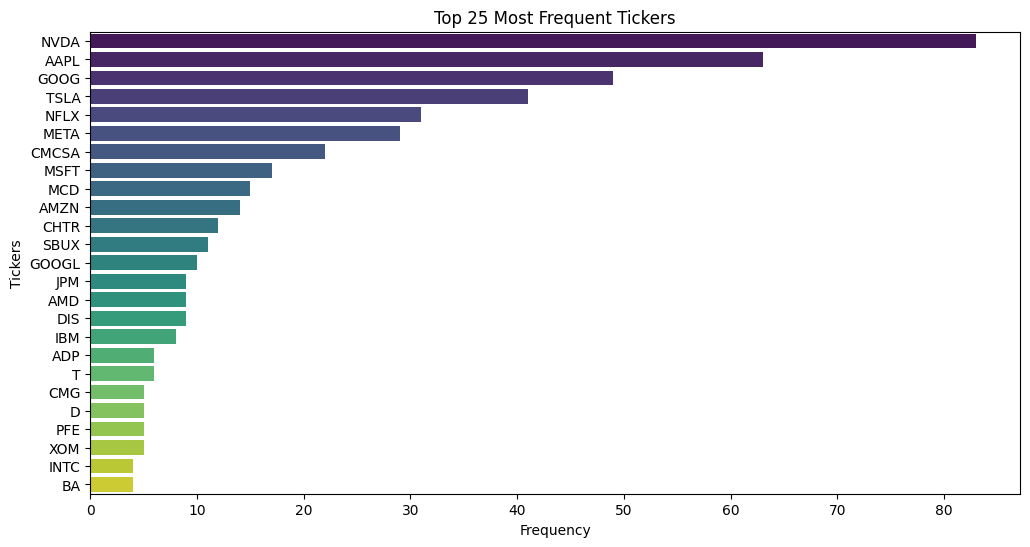

In [18]:
ticker_count = df['ticker'].value_counts()[:25]

plt.figure(figsize=(12, 6))
sns.barplot(x=ticker_count.values, y=ticker_count.index, palette='viridis')
plt.xlabel('Frequency')
plt.ylabel('Tickers')
plt.title('Top 25 Most Frequent Tickers')
plt.show()

### Выводы ###

- Размеченный датасет получился слишком мальнький для обучения модели только на данных из твиттера. В текущем состоянии его можно использовать в качестве дополнительных данных для более объемной модели.
- Проблема малого кол-ва объектов в дата сете связана в первую очередь с не самым оптимальным подходом для сбора данных из твитера. Так же это связано с недостатком наименований компаний на этапе выявления тикеров из уже собранных твитов.

### Что можно исправить? ###

- Оптимизировать парсер
- Добавить больше наименований компаний